# **4장 : 분류**
# **4.6 XGBoost**
# **4.7 LightGBM**
# **4.8 하이퍼 파라미터 튜닝**

# 4.6 XGBoost(eXtra Gradient Boost)
# 파이썬 래퍼 XGVoost 모듈 (초기의 독자적인 XGBoost 프레임워크 기반)
GBM의 단점인 느린 수행 시간과 과적합 규제 부재 문제를 해결. 병렬 학습도 가능해서 빨리 학습 가능.

In [1]:
import importlib.metadata
print(importlib.metadata.version("xgboost"))

1.7.6


In [2]:
import xgboost as xgb
# 피처 중요도 시각화 모듈
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()
features = dataset.data
labels = dataset.target

cancer_df = pd.DataFrame(data=features, columns = dataset.feature_names)
cancer_df['target'] = labels
cancer_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [3]:
print(dataset.target_names)
print(cancer_df['target'].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [4]:
X_features = cancer_df.iloc[:,:-1]
y_label = cancer_df.iloc[:,-1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state = 156)

# 학습용 데이터 중 90% 학습, 10% 검증용 데이터로 분리
X_tr, X_validate, y_tr,y_validate = train_test_split(X_train,y_train,test_size=0.1,random_state=156)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_validate.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


파이썬 래퍼 XGBoost와 사이킷런의 차이  
DMatrix 사용 -> Numpy, Pandas의 데이터 세트를 모두 DMatrix로 변형해 주어야 함  

In [5]:
data_train = xgb.DMatrix(data=X_tr, label = y_tr)
data_validate = xgb.DMatrix(data = X_validate, label = y_validate)
data_test = xgb.DMatrix(data = X_test, label = y_test)

max_depth : 트리의 최대 깊이  
eta : learning rate  
objective : 목적함수 (예제 데이터가 0 또는 1 이진 분류이므로 이진 로지스틱)  
eval_matrix : loss function의 평가 지표  
num_rounds : 부스팅 반복 횟수  

In [6]:
params = {'max_depth' : 3,
          'eta' : 0.05, 
          'objective':'binary:logistic',
          'eval_metric':'logloss'}
num_rounds = 400

In [7]:
eval_list = [(data_train,'train'),(data_validate,'eval')]

xgb_model = xgb.train(params = params, dtrain = data_train, num_boost_round = num_rounds,
                      early_stopping_rounds = 50, evals = eval_list)

[0]	train-logloss:0.65016	eval-logloss:0.66183
[1]	train-logloss:0.61131	eval-logloss:0.63609
[2]	train-logloss:0.57563	eval-logloss:0.61144
[3]	train-logloss:0.54310	eval-logloss:0.59204
[4]	train-logloss:0.51323	eval-logloss:0.57329
[5]	train-logloss:0.48447	eval-logloss:0.55037
[6]	train-logloss:0.45796	eval-logloss:0.52930
[7]	train-logloss:0.43436	eval-logloss:0.51534
[8]	train-logloss:0.41150	eval-logloss:0.49718
[9]	train-logloss:0.39027	eval-logloss:0.48154
[10]	train-logloss:0.37128	eval-logloss:0.46990
[11]	train-logloss:0.35254	eval-logloss:0.45474
[12]	train-logloss:0.33528	eval-logloss:0.44229
[13]	train-logloss:0.31892	eval-logloss:0.42961
[14]	train-logloss:0.30439	eval-logloss:0.42065
[15]	train-logloss:0.29000	eval-logloss:0.40958
[16]	train-logloss:0.27651	eval-logloss:0.39887
[17]	train-logloss:0.26389	eval-logloss:0.39050
[18]	train-logloss:0.25210	eval-logloss:0.38254
[19]	train-logloss:0.24123	eval-logloss:0.37393
[20]	train-logloss:0.23076	eval-logloss:0.36789
[2

In [8]:
pred_probs = xgb_model.predict(data_test)
print('predict() 수행 결괏값을 10개만 표시, 예측 확률 값으로 표시됨')
print(np.round(pred_probs[:10],3))

preds = [1 if x>0.5 else 0 for x in pred_probs]
print('예측값 10개만 표시 : ',preds[:10])

predict() 수행 결괏값을 10개만 표시, 예측 확률 값으로 표시됨
[0.845 0.008 0.68  0.081 0.975 0.999 0.998 0.998 0.996 0.001]
예측값 10개만 표시 :  [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
def get_clf_eval(y_test,pred,pred_proba):
    confusion = confusion_matrix(y_test,pred)
    accuracy = accuracy_score(y_test,pred)
    precision = precision_score(y_test,pred)
    recall = recall_score(y_test,pred)
    f1 = f1_score(y_test,pred)
    roc_auc = roc_auc_score(y_test,pred_proba)
    print('오차 행렬')
    print(confusion)
    print('Accuracy: {0:.4f}, Precision: {1:.4f}, Recall: {2:.4f}, F1: {3:.4f}, AUC: {4:.4f}'.format(accuracy,precision,recall,f1,roc_auc))


get_clf_eval(y_test,preds,pred_probs)

오차 행렬
[[34  3]
 [ 2 75]]
Accuracy: 0.9561, Precision: 0.9615, Recall: 0.9740, F1: 0.9677, AUC: 0.9937


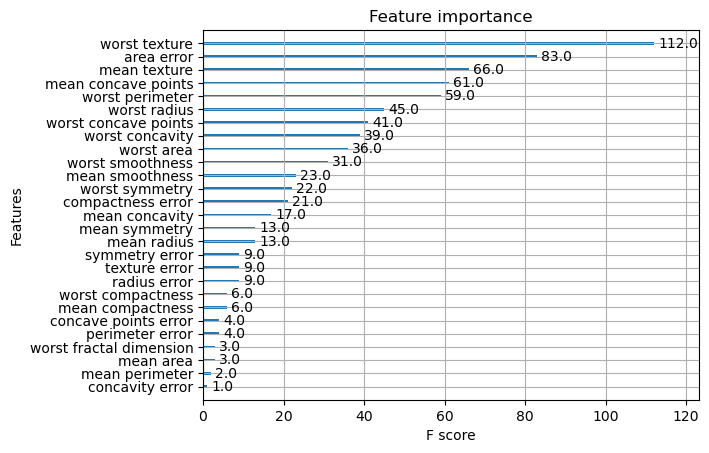

In [10]:
import xgboost as xgb
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

plot_importance(xgb_model)
plt.show()

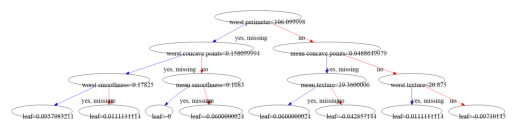

In [11]:
import xgboost as xgb
from xgboost import plot_tree
import matplotlib.pyplot as plt
%matplotlib inline

plot_tree(xgb_model, num_trees=0)
plt.show()

# 사이킷런 래퍼 XGBoost (사이킷런의 프레임워크와 연동)
XGBClassifier, XBGRegressor  
아까 전이랑 다른 점  
eta -> learning_rate  
sub_sample -> subsample  
lambda = reg_lambda  
alpha -> reg_alpha  

In [12]:
from xgboost import XGBClassifier

xgb_wrapper = XGBClassifier(n_estimators = 400, learning_rate = 0.05, max_depth = 3, eval_metric='logloss')
xgb_wrapper.fit(X_train,y_train,verbose=True)
w_preds = xgb_wrapper.predict(X_test)
w_pred_proba = xgb_wrapper.predict_proba(X_test)[:,1]
get_clf_eval(y_test,w_preds,w_pred_proba)

오차 행렬
[[34  3]
 [ 1 76]]
Accuracy: 0.9649, Precision: 0.9620, Recall: 0.9870, F1: 0.9744, AUC: 0.9954


In [13]:
import xgboost
print(xgboost.__version__)

1.7.6


In [14]:
from xgboost import XGBClassifier
xgb_wrapper = XGBClassifier(n_estimators = 400, learning_rate = 0.5, max_depth = 3)
evals = [(X_train,y_train),(X_validate,y_validate)]
xgb_wrapper.fit(X_train,y_train, eval_set=evals, early_stopping_rounds=50, eval_metric="logloss",verbose=True)
ws50_preds = xgb_wrapper.predict(X_test)
ws50_pred_proba = xgb_wrapper.predict_proba(X_test)[:,1]

[0]	validation_0-logloss:0.35699	validation_1-logloss:0.38471
[1]	validation_0-logloss:0.21754	validation_1-logloss:0.27358
[2]	validation_0-logloss:0.14795	validation_1-logloss:0.20455
[3]	validation_0-logloss:0.10391	validation_1-logloss:0.15540
[4]	validation_0-logloss:0.07756	validation_1-logloss:0.11760
[5]	validation_0-logloss:0.06210	validation_1-logloss:0.09922
[6]	validation_0-logloss:0.04976	validation_1-logloss:0.08568
[7]	validation_0-logloss:0.04131	validation_1-logloss:0.08152
[8]	validation_0-logloss:0.03422	validation_1-logloss:0.07378
[9]	validation_0-logloss:0.02821	validation_1-logloss:0.06281
[10]	validation_0-logloss:0.02426	validation_1-logloss:0.05414
[11]	validation_0-logloss:0.02093	validation_1-logloss:0.04584
[12]	validation_0-logloss:0.01831	validation_1-logloss:0.04380
[13]	validation_0-logloss:0.01617	validation_1-logloss:0.03655
[14]	validation_0-logloss:0.01462	validation_1-logloss:0.03342
[15]	validation_0-logloss:0.01372	validation_1-logloss:0.03223
[1

In [15]:
get_clf_eval(y_test,ws50_preds,ws50_pred_proba)

오차 행렬
[[34  3]
 [ 2 75]]
Accuracy: 0.9561, Precision: 0.9615, Recall: 0.9740, F1: 0.9677, AUC: 0.9947


In [16]:
xgb_wrapper.fit(X_train,y_train, eval_set=evals, early_stopping_rounds=10, eval_metric="logloss",verbose=True)
ws10_preds = xgb_wrapper.predict(X_test)
ws10_pred_proba = xgb_wrapper.predict_proba(X_test)[:,1]
get_clf_eval(y_test,ws10_preds,ws10_pred_proba)

[0]	validation_0-logloss:0.35699	validation_1-logloss:0.38471
[1]	validation_0-logloss:0.21754	validation_1-logloss:0.27358
[2]	validation_0-logloss:0.14795	validation_1-logloss:0.20455
[3]	validation_0-logloss:0.10391	validation_1-logloss:0.15540
[4]	validation_0-logloss:0.07756	validation_1-logloss:0.11760
[5]	validation_0-logloss:0.06210	validation_1-logloss:0.09922
[6]	validation_0-logloss:0.04976	validation_1-logloss:0.08568
[7]	validation_0-logloss:0.04131	validation_1-logloss:0.08152
[8]	validation_0-logloss:0.03422	validation_1-logloss:0.07378
[9]	validation_0-logloss:0.02821	validation_1-logloss:0.06281
[10]	validation_0-logloss:0.02426	validation_1-logloss:0.05414
[11]	validation_0-logloss:0.02093	validation_1-logloss:0.04584
[12]	validation_0-logloss:0.01831	validation_1-logloss:0.04380
[13]	validation_0-logloss:0.01617	validation_1-logloss:0.03655
[14]	validation_0-logloss:0.01462	validation_1-logloss:0.03342
[15]	validation_0-logloss:0.01372	validation_1-logloss:0.03223
[1

# LightGBM
XGBoost보다 학습 시간 훨신 적음. (데이터 10000건 이상일 때)  
XGBoost는 균형 트리 분할 (트리의 깊이 최소화, 오버피팅방지) 인데  
LightGBM은 리프 중심 트리 분할 (최대 손실 값을 가지는 리프 노트 지속적 분할, 비대칭적 트리)임 
## 마찬가지로 lightbgm 패키지 안에 파이썬 래퍼용(초기), 사이킷런 래퍼용 두 가지가 존재

In [23]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data = dataset.data, columns = dataset.feature_names)

cancer_df['target'] = dataset.target
X_features = cancer_df.iloc[:,:-1]
y_label = cancer_df.iloc[:,-1]

X_train, X_test,y_train,y_test = train_test_split(X_features,y_label,test_size = 0.2, random_state = 156)

X_tr, X_val, y_tr, y_val = train_test_split(X_train,y_train,test_size=0.1,random_state = 156)

lgbm_wrapper = LGBMClassifier(n_estimators = 400, learning_rate = 0.5)

evals = [(X_tr, y_tr),(X_val,y_val)]
lgbm_wrapper.fit(X_tr,y_tr,callbacks=[early_stopping(stopping_rounds=50),log_evaluation(period=10)], eval_metric = "logloss", eval_set = evals)
preds = lgbm_wrapper.predict(X_test)
pred_proba = lgbm_wrapper.predict_proba(X_test)[:,1]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 251, number of negative: 158
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000323 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4092
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 30
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.613692 -> initscore=0.462858
[LightGBM] [Info] Start training from score 0.462858
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [24]:
get_clf_eval(y_test,preds,pred_proba)

오차 행렬
[[34  3]
 [ 2 75]]
Accuracy: 0.9561, Precision: 0.9615, Recall: 0.9740, F1: 0.9677, AUC: 0.9909


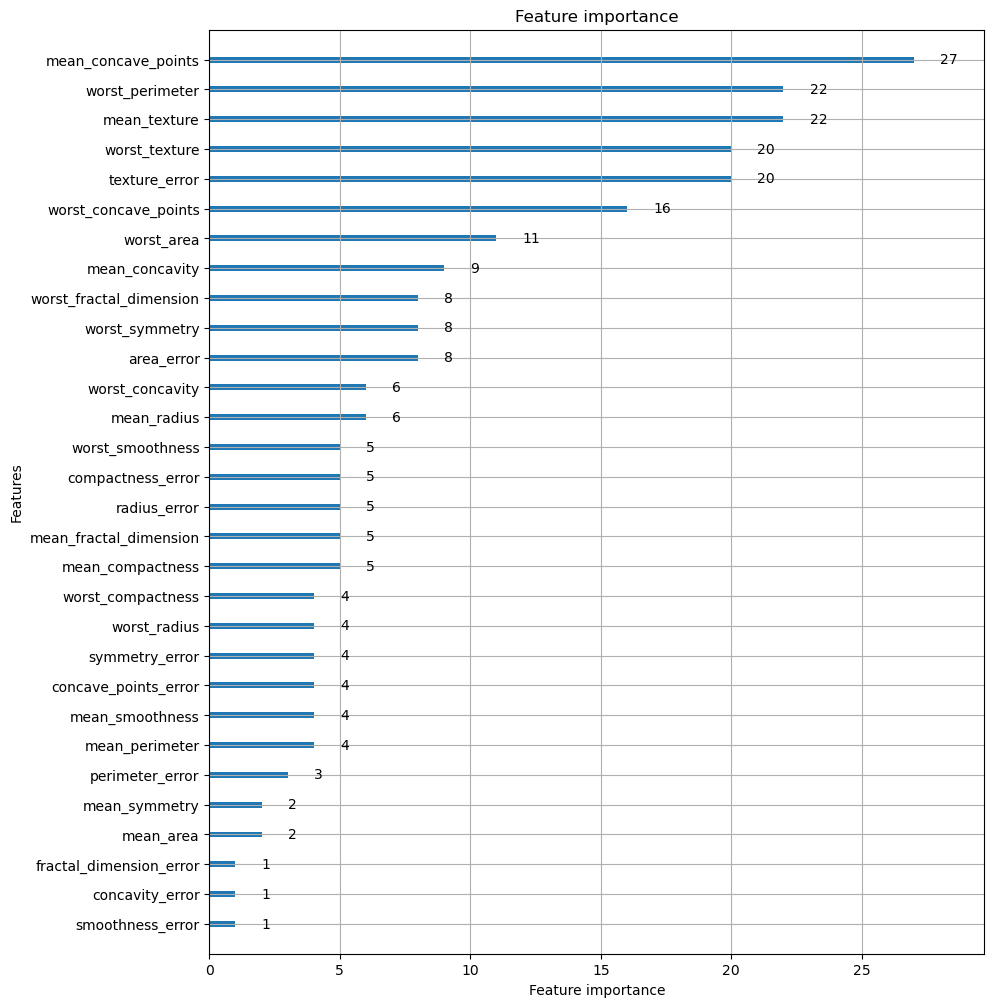

In [26]:
from lightgbm import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fit, ax = plt.subplots(figsize = (10, 12))
plot_importance(lgbm_wrapper,ax=ax)
plt.show()

# 4.8 베이지안 최적화 기반의 HyperOpt를 이용한 하이퍼파라미터 튜닝
XGBoost나 LightGBM은 하이퍼 파라미터의 개수가 많고, 이를 GridSearchCV를 이용해서 최적의 하이퍼파라미터를 찾아야 함.  
그러나 이는 시간 매우 오래 걸림. -> 베이지안 최적화를 사용하자  

In [30]:
from hyperopt import hp

# 입력 변수명과 입력값의 검색 공간 설정
search_space = {'x':hp.quniform('x',-10,10,1),'y':hp.quniform('y',-15,15,1)}

# 목적 함수 생성
from hyperopt import STATUS_OK

def objective_func(search_space):
    x = search_space['x']
    y = search_space['y']
    retval = x**2-20*y
    return retval

In [32]:
# 입력값의 검색 공간과 목적 함수를 설정했으면 목적 함수의 반환값이 최소가 될 수 있는 최적의 입력값 찾아야 함
# 베이지안 최적화 기법에 기반하여 찾음
# hyperopt는 fmin함수 제공
# fn : 목적 함수
# space : 검색 공간
# algo : 베이지안 최적화 적용 알고리즘
# max_evals : 최적 입력값을 찾기 위한 입력값 시도 횟수
# trials : 최적 입력값을 찾기 위해 시도한 입력값 및 해당 입력값의 목적 함수 반환값 결과 저장
# rstate : random seed
from hyperopt import fmin,tpe,Trials
trial_val = Trials()

best_01 = fmin(fn = objective_func, space = search_space, algo = tpe.suggest, max_evals = 5,
               trials = trial_val, rstate = np.random.default_rng(seed=0))
print('best: ',best_01)

100%|█████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 881.67trial/s, best loss: -224.0]
best:  {'x': -4.0, 'y': 12.0}


In [33]:
from hyperopt import fmin,tpe,Trials
trial_val = Trials()

best_02 = fmin(fn = objective_func, space = search_space, algo = tpe.suggest, max_evals = 20,
               trials = trial_val, rstate = np.random.default_rng(seed=0))
print('best: ',best_02)

100%|██████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 1710.63trial/s, best loss: -296.0]
best:  {'x': 2.0, 'y': 15.0}


## Trials 객체의 results, vals : fmin 함수의 수행 시마다 최적화되는 경과를 볼 수 있음

In [34]:
print(trial_val.results)

[{'loss': -64.0, 'status': 'ok'}, {'loss': -184.0, 'status': 'ok'}, {'loss': 56.0, 'status': 'ok'}, {'loss': -224.0, 'status': 'ok'}, {'loss': 61.0, 'status': 'ok'}, {'loss': -296.0, 'status': 'ok'}, {'loss': -40.0, 'status': 'ok'}, {'loss': 281.0, 'status': 'ok'}, {'loss': 64.0, 'status': 'ok'}, {'loss': 100.0, 'status': 'ok'}, {'loss': 60.0, 'status': 'ok'}, {'loss': -39.0, 'status': 'ok'}, {'loss': 1.0, 'status': 'ok'}, {'loss': -164.0, 'status': 'ok'}, {'loss': 21.0, 'status': 'ok'}, {'loss': -56.0, 'status': 'ok'}, {'loss': 284.0, 'status': 'ok'}, {'loss': 176.0, 'status': 'ok'}, {'loss': -171.0, 'status': 'ok'}, {'loss': 0.0, 'status': 'ok'}]


In [35]:
print(trial_val.vals)

{'x': [-6.0, -4.0, 4.0, -4.0, 9.0, 2.0, 10.0, -9.0, -8.0, -0.0, -0.0, 1.0, 9.0, 6.0, 9.0, 2.0, -2.0, -4.0, 7.0, -0.0], 'y': [5.0, 10.0, -2.0, 12.0, 1.0, 15.0, 7.0, -10.0, 0.0, -5.0, -3.0, 2.0, 4.0, 10.0, 3.0, 3.0, -14.0, -8.0, 11.0, -0.0]}


In [36]:
import pandas as pd

losses = [loss_dict['loss'] for loss_dict in trial_val.results]

result_df = pd.DataFrame({'x' : trial_val.vals['x'], 'y' : trial_val.vals['y'], 'losses' : losses})
result_df

,x,y,losses
0,-6.0,5.0,-64.0
1,-4.0,10.0,-184.0
2,4.0,-2.0,56.0
3,-4.0,12.0,-224.0
4,9.0,1.0,61.0
5,2.0,15.0,-296.0
6,10.0,7.0,-40.0
7,-9.0,-10.0,281.0
8,-8.0,0.0,64.0
9,-0.0,-5.0,100.0


## hyperopt를 이용한 XGBoost 하이퍼 파라미터 최적화

In [41]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data = dataset.data, columns = dataset.feature_names)

cancer_df['target'] = dataset.target
X_features = cancer_df.iloc[:,:-1]
y_label = cancer_df.iloc[:,-1]

X_train, X_test,y_train,y_test = train_test_split(X_features,y_label,test_size = 0.2, random_state = 156)

X_tr, X_val, y_tr, y_val = train_test_split(X_train,y_train,test_size=0.1,random_state = 156)

from hyperopt import hp

xgb_search_space = {'max_depth' : hp.quniform('max_depth', 5, 20, 1),
                    'min_child_weight' : hp.quniform('min_child_weight',1,2,1),
                    'learning_rate' : hp.uniform('learning_rate',0.01,0.2),
                    'colsample_bytree' : hp.uniform('colsample_bytree',0.5,1)}
                                                 

### hp.quniform은 실수형임. 모두 정수형으로 변환해주어야 함.
### Hyperopt의 목적 함수는 최솟값을 반환할 수 있도록 최적화해야함. 정확도와 같은 성능 지표일 겨우 -1 곱해주어야 함.

In [44]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from hyperopt import STATUS_OK

def objective_func(search_space):
    xgb_clf = XGBClassifier(n_estimators = 100, max_depth = int(search_space['max_depth']),
                            min_child_weight = int(search_space['min_child_weight']),
                            learning_rate = search_space['learning_rate'],
                            colsample_bytree = search_space['colsample_bytree'],
                            eval_metric = 'logloss')
    accuracy = cross_val_score(xgb_clf, X_train, y_train, scoring='accuracy', cv=3)
    return {'loss':-1*np.mean(accuracy), 'status':STATUS_OK}

In [45]:
from hyperopt import fmin,tpe,Trials
trial_val=Trials()
best = fmin(fn = objective_func, space = xgb_search_space, algo = tpe.suggest, max_evals = 50,
            trials = trial_val, rstate = np.random.default_rng(seed=9))
print('best:', best)

100%|███████████████████████████████████████████████| 50/50 [00:16<00:00,  3.08trial/s, best loss: -0.9670616939700244]
best: {'colsample_bytree': 0.5424149213362504, 'learning_rate': 0.12601372924444681, 'max_depth': 17.0, 'min_child_weight': 2.0}


In [47]:
print('colsample_bytree:{0}, learning_rate:{1}, max_depth:{2}, min_child_weight : {3}'.format(
    round(best['colsample_bytree'],5),round(best['learning_rate'],5),int(best['max_depth']),int(best['min_child_weight'])))

colsample_bytree:0.54241, learning_rate:0.12601, max_depth:17, min_child_weight : 2


In [48]:
from xgboost import XGBClassifier
xgb_wrapper = XGBClassifier(n_estimators = 400, 
                            learning_rate = round(best['learning_rate'],5), 
                            max_depth = int(best['max_depth']),
                           min_child_weight = int(best['min_child_weight']),
                           colsample_bytree = round(best['colsample_bytree'],5))
evals = [(X_tr,y_tr),(X_val,y_val)]
xgb_wrapper.fit(X_tr,y_tr, eval_set=evals, early_stopping_rounds=50, eval_metric="logloss",verbose=True)
preds = xgb_wrapper.predict(X_test)
pred_proba = xgb_wrapper.predict_proba(X_test)[:,1]

get_clf_eval(y_test,preds,pred_proba)

[0]	validation_0-logloss:0.58942	validation_1-logloss:0.62048
[1]	validation_0-logloss:0.50801	validation_1-logloss:0.55913
[2]	validation_0-logloss:0.44160	validation_1-logloss:0.50928
[3]	validation_0-logloss:0.38734	validation_1-logloss:0.46815
[4]	validation_0-logloss:0.34224	validation_1-logloss:0.43913
[5]	validation_0-logloss:0.30425	validation_1-logloss:0.41570
[6]	validation_0-logloss:0.27178	validation_1-logloss:0.38953
[7]	validation_0-logloss:0.24503	validation_1-logloss:0.37317
[8]	validation_0-logloss:0.22050	validation_1-logloss:0.35628
[9]	validation_0-logloss:0.19873	validation_1-logloss:0.33798
[10]	validation_0-logloss:0.17945	validation_1-logloss:0.32463
[11]	validation_0-logloss:0.16354	validation_1-logloss:0.31384
[12]	validation_0-logloss:0.15032	validation_1-logloss:0.30607
[13]	validation_0-logloss:0.13813	validation_1-logloss:0.30143
[14]	validation_0-logloss:0.12798	validation_1-logloss:0.29513
[15]	validation_0-logloss:0.11926	validation_1-logloss:0.28891
[1